In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [32]:
df = pd.read_csv(r"C:\Users\sahil\OneDrive\ドキュメント\Automobile Warranty Claim\data\02.Processed\Cleaned_Crop_Yield.csv")

In [33]:
df.head()

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,NaN,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71


In [34]:
df.drop(["Region","Previous_Crop"],inplace = True,axis = 1)

In [35]:
df.reset_index(drop = True)

,Crop,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Yield_ton_per_ha
0,Maize,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,101.48
1,Barley,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,127.39
2,Rice,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,68.99
3,Maize,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,169.06
4,Maize,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,118.71
...,...,...,...,...,...,...,...,...,...,...,...
9995,Barley,Clay,5.84,890.4,28.5,68.6,82.5,Flood,4.0,24.1,79.83
9996,Maize,Sandy,6.91,614.2,30.0,84.2,85.2,Unknown,21.7,8.3,68.24
9997,Wheat,Clay,6.98,842.0,22.6,75.1,249.2,Sprinkler,8.8,18.1,159.29
9998,Wheat,Sandy,7.27,924.2,26.8,50.8,146.1,Sprinkler,3.3,18.1,99.08


In [36]:
num_cols = df.select_dtypes(include=["int","float"]).drop(columns = "Yield_ton_per_ha" ).columns
cat_cols = df.select_dtypes(include=["O"]).columns

In [37]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
print(f"Training Shape :- {x_train.shape}, {x_test.shape}")
print(f"Testing Shape :-  {y_train.shape}, {y_test.shape}")

Training Shape :- (8000, 10), (2000, 10)
Testing Shape :-  (8000,), (2000,)


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [41]:
models = {
    'Linear Regression': LinearRegression(fit_intercept=True),
    'KNN Regression': KNeighborsRegressor(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(n_estimators=500,max_depth = 10,max_features = 1.0,min_samples_leaf=4,min_samples_split=10,random_state=42),
    'Support Vector Regression': SVR()
}

In [42]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    [
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models)
])

Model: Linear Regression
R2 Score :-  0.9821379137610299
RMSE :-  5.078652405434214
MAE :-  4.075621445730116


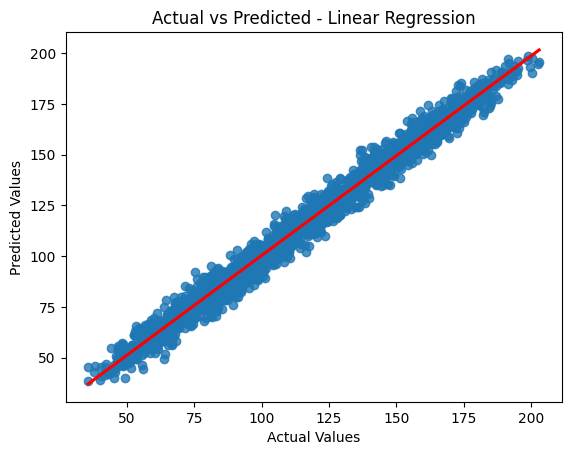

--------------------------------------------------
Model: KNN Regression
R2 Score :-  0.8860851619123508
RMSE :-  12.825448095563756
MAE :-  10.425182000000001


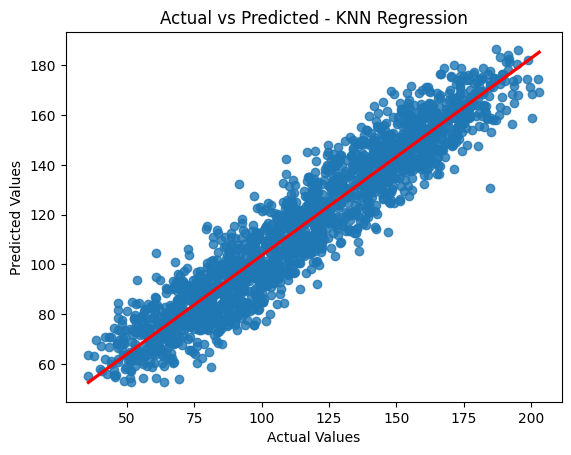

--------------------------------------------------
Model: Decision Tree Regression
R2 Score :-  0.9619340015230954
RMSE :-  7.413973199304136
MAE :-  5.9124


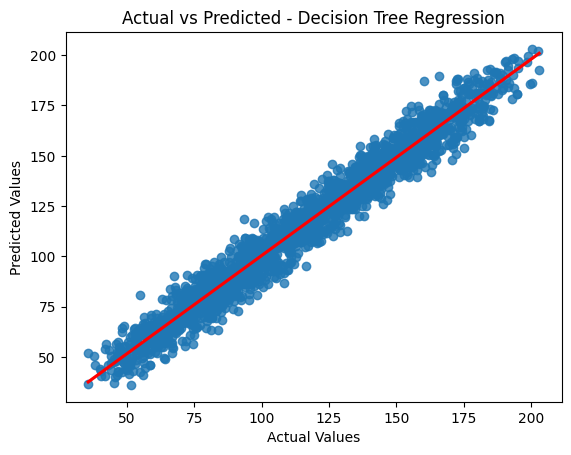

--------------------------------------------------
Model: Random Forest Regression
R2 Score :-  0.9804355980759024
RMSE :-  5.315151977637146
MAE :-  4.279217216860663


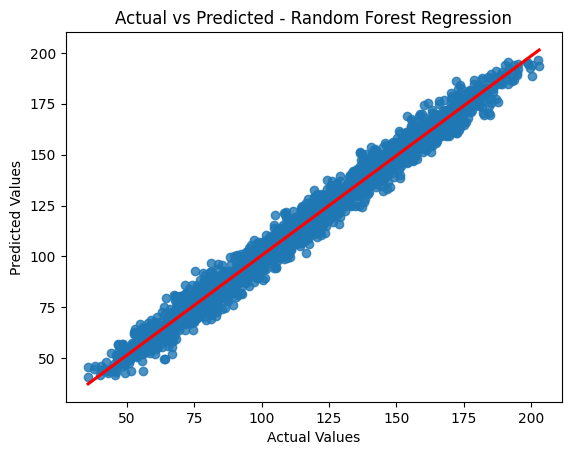

--------------------------------------------------
Model: Support Vector Regression
R2 Score :-  0.9569143751341044
RMSE :-  7.887667533797501
MAE :-  6.082399554606409


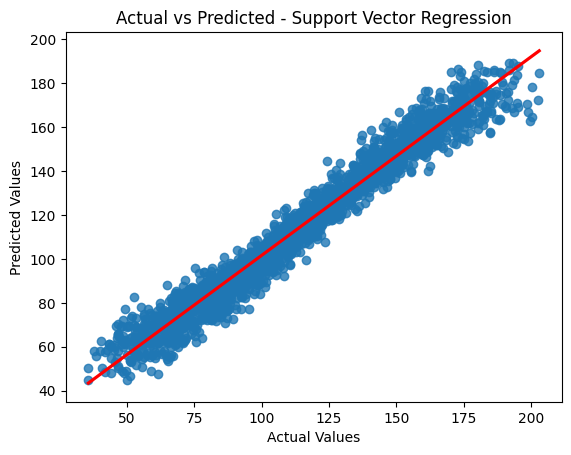

--------------------------------------------------


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, r2_score,mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

for model_name, model in models.items(): 

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train the model
    model_pipeline.fit(x_train, y_train)

    # Predict
    y_pred = model_pipeline.predict(x_test)  

    # Evaluation
    print(f"Model: {model_name}")
    print("R2 Score :- ", r2_score(y_test, y_pred))
    print("RMSE :- ", root_mean_squared_error(y_test, y_pred))
    print("MAE :- ",mean_absolute_error(y_test,y_pred))

    # Regression plot
    sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.show()

    print("-" * 50)



In [45]:
from sklearn.model_selection import KFold,cross_val_score
for model_name,model in models.items():
    # Define K-Fold
    kf = KFold(n_splits=5,shuffle=True,random_state=42)

    # R2 Score
    r2_scores = cross_val_score(model_pipeline,x_train,y_train,cv=kf,scoring='r2')
    print(model_name)
    print(r2_scores.max())
    print("-"*50)


Linear Regression
0.95788518578429
--------------------------------------------------
KNN Regression
0.95788518578429
--------------------------------------------------
Decision Tree Regression
0.95788518578429
--------------------------------------------------
Random Forest Regression
0.95788518578429
--------------------------------------------------
Support Vector Regression
0.95788518578429
--------------------------------------------------


In [46]:
from sklearn.model_selection import GridSearchCV
# Random Forest
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Hyperparameters
rf_param_grid = {
    'model__n_estimators': [100,200,300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt']
}

# Grid Search
rf_grid = GridSearchCV(
    estimator=model_pipeline,
    param_grid=rf_param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit
rf_grid.fit(x_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__max_features': 1.0, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV RMSE: 5.2885407441232735


In [47]:
# Tuned Random Forest pipeline
rf_tuned_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        max_features=1.0,
        min_samples_leaf=4,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_tuned_pipeline.fit(x_train, y_train)

# Predict
y_train_pred = rf_tuned_pipeline.predict(x_train)
y_pred = rf_tuned_pipeline.predict(x_test)

# Training Evaluate
print("Training :- ")
r2 = r2_score(y_train, y_train_pred)
rmse = root_mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train,y_train_pred)

print("Tuned Random Forest R²:", r2)
print("Tuned Random Forest RMSE:", rmse)
print("Tuned Random Forest MAE:", mae)


# Testing Evaluate
print("Testing")
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)


print("Tuned Random Forest R²:", r2)
print("Tuned Random Forest RMSE:", rmse)
print("Tuned Random Forest MAE:", mae)


Training :- 
Tuned Random Forest R²: 0.9908649797666856
Tuned Random Forest RMSE: 3.627891357465419
Tuned Random Forest MAE: 2.8570345591104584
Testing
Tuned Random Forest R²: 0.9804276601267811
Tuned Random Forest RMSE: 5.316230138047491
Tuned Random Forest MAE: 4.280343839750843


In [48]:
# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
# Hyperparameter grid
lr_param_grid = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}
# GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
lr_grid.fit(x_train, y_train)
print("Best Parameters:", lr_grid.best_params_)
print("Best CV RMSE:", -lr_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'model__fit_intercept': True, 'model__positive': True}
Best CV RMSE: 5.011619500815761


In [49]:
# Tuned Linear  Regression pipeline
lr_tuned_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression(
        fit_intercept=True,positive=True))
])

# Train
lr_tuned_pipeline.fit(x_train, y_train)

# Predict
y_train_pred = lr_tuned_pipeline.predict(x_train)
y_pred = rf_tuned_pipeline.predict(x_test)

# Training Evaluate
print("Training :- ")
r2 = r2_score(y_train, y_train_pred)
rmse = root_mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train,y_train_pred)

print("Tuned Linear Regrssion R²:", r2)
print("Tuned Linear Regression RMSE:", rmse)
print("Tuned Linear Regression MAE:", mae)

# Testing Evaluate
print("Testing :- ")

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)

print("Tuned Linear Regrssion R²:", r2)
print("Tuned Linear Regression RMSE:", rmse)
print("Tuned Linear Regression MAE:", mae)

Training :- 
Tuned Linear Regrssion R²: 0.9826273970143706
Tuned Linear Regression RMSE: 5.003016827558064
Tuned Linear Regression MAE: 3.9704537015507784
Testing :- 
Tuned Linear Regrssion R²: 0.9804276601267811
Tuned Linear Regression RMSE: 5.31623013804749
Tuned Linear Regression MAE: 4.280343839750843


In [50]:
lr_tuned_pipeline.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
import pickle
with open("model.pkl","wb") as file:
    pickle.dump(lr_tuned_pipeline,file)

In [2]:
import sys
print(sys.executable)

c:\Users\sahil\AppData\Local\Programs\Python\Python313\python.exe
